Interactive conversion of GHL from COGs to IceChunk as part of distribution via Earthmover. Following: https://icechunk.io/en/stable/guides/ingestion/glad-ingest/ for the general idea.

Ticket: https://github.com/Space-Intelligence/issues/issues/1381

In [11]:
# ---- Imports ----
import datetime
import itertools
import pathlib
import warnings

import coiled
import dask
import dask.array
import icechunk as ic
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray as rxr
import xarray as xr
import yaml
from azure.identity import DefaultAzureCredential
from azure.storage.blob import BlobServiceClient, BlobSasPermissions, generate_blob_sas
from distributed import wait
from icechunk.session import ForkSession
from icechunk.xarray import to_icechunk
from odc.geo.geobox import GeoBox
from rasterio.env import Env

rxr.set_options(export_grid_mapping=False)

# Suppress xarray's chunk-alignment warning — we intentionally open COGs at larger
# chunks than their internal block size to reduce dask task count.
warnings.filterwarnings("ignore", message=".*separate the stored chunks.*", category=UserWarning)

ICECHUNK_ACCOUNT = "spaceintelliexternal"
ICECHUNK_CONTAINER = "earthmover"
ICECHUNK_PREFIX = "ghl/2025/v1"

DASK_CHUNK_SIZE = (1, 10000, 10000)  # 200MB per chunk for uint16, 100MB for uint8; 4×4 = 16 chunks per tile

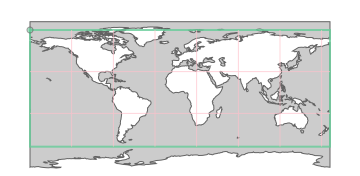

In [10]:
# ---- Load config and set up Azure storage client + SAS URL helper ----
ASSETS_PATH = pathlib.Path("assets.yaml")

with ASSETS_PATH.open() as f:
    assets_cfg = yaml.safe_load(f)

YEAR = int(list(assets_cfg["dates"].keys())[0])   # 2024
TILES = assets_cfg["tiles"]
PREFIX = assets_cfg["storage"]["prefix"]          # {"forest_carbon": ..., ...}

STORAGE_ACCOUNT = assets_cfg["storage"]["account"]
CONTAINER = assets_cfg["storage"]["container"]

credential = DefaultAzureCredential()

_blob_service_client = BlobServiceClient(
    account_url=f"https://{STORAGE_ACCOUNT}.blob.core.windows.net",
    credential=credential,
)

def tile_url(asset_type: str, tile: str) -> str:
    """Return a signed read URL for a GHL COG tile."""
    blob_name = f"{PREFIX[asset_type]}/{tile}.tif"

    expiry = datetime.datetime.now(datetime.timezone.utc) + datetime.timedelta(hours=6)
    start = datetime.datetime.now(datetime.timezone.utc) - datetime.timedelta(minutes=5)

    user_delegation_key = _blob_service_client.get_user_delegation_key(
        key_start_time=start,
        key_expiry_time=expiry,
    )
    sas_token = generate_blob_sas(
        account_name=STORAGE_ACCOUNT,
        container_name=CONTAINER,
        blob_name=blob_name,
        user_delegation_key=user_delegation_key,
        permission=BlobSasPermissions(read=True),
        expiry=expiry,
        start=start,
    )
    return (
        f"https://{STORAGE_ACCOUNT}.blob.core.windows.net"
        f"/{CONTAINER}/{blob_name}?{sas_token}"
    )

# 10 deg tile at 40k px => 0.00025 deg/px
RES = 0.00025

# Full GHL coverage: lon -180..180, lat -60..80
GLOBAL_BBOX = (-180.0, -60.0, 180.0, 80.0)

global_gbox = GeoBox.from_bbox(
    GLOBAL_BBOX,
    crs="EPSG:4326",
    resolution=RES,
    anchor="edge",
)
global_gbox

In [3]:
# ---- Define read_tile: reads one COG tile for one year as a lazy xarray Dataset ----
def read_tile(
    tile: str,
    year: int = YEAR,
    *,
    chunks: dict | None = {},
    urls: dict[str, str] | None = None,
) -> xr.Dataset:
    """
    Read one GHL tile (e.g. '70N_180W') for one year, returning a Dataset with:
    - deforestation
    - land_cover
    - forest_carbon

    Pass pre-generated `urls` (dict of asset -> SAS URL) when running on workers
    that lack Azure credentials. If omitted, URLs are generated via tile_url().
    """
    assets = {
        "deforestation": "deforestation",
        "land_cover": "land_cover",
        "forest_carbon": "forest_carbon",
    }

    vars_ds: list[xr.Dataset] = []
    with Env(GDAL_CACHEMAX=0, VSI_CACHE=False, VSI_CACHE_SIZE=0):
        for asset_key, var_name in assets.items():
            url = urls[asset_key] if urls else tile_url(asset_key, tile)
            ds_asset = (
                xr.open_dataset(
                    url,
                    engine="rasterio",
                    chunks=chunks,
                    mask_and_scale=False,
                    lock=False,
                )
                .rename({"band_data": var_name})
                .squeeze("band", drop=True)
                .expand_dims(year=[year])
            )
            vars_ds.append(ds_asset)

    return xr.merge(vars_ds, compat="override", join="exact")


ds = read_tile(tile="70N_180W", year=YEAR, chunks={"x": DASK_CHUNK_SIZE[2], "y": DASK_CHUNK_SIZE[1]})
ds

<xarray.Dataset> Size: 6GB
Dimensions:        (year: 1, x: 40000, y: 40000)
Coordinates:
  * year           (year) int64 8B 2024
  * x              (x) float64 320kB -180.0 -180.0 -180.0 ... -170.0 -170.0
  * y              (y) float64 320kB 70.0 70.0 70.0 70.0 ... 60.0 60.0 60.0 60.0
    spatial_ref    int64 8B ...
Data variables:
    deforestation  (year, y, x) uint8 2GB dask.array<chunksize=(1, 10000, 10000), meta=np.ndarray>
    land_cover     (year, y, x) uint8 2GB dask.array<chunksize=(1, 10000, 10000), meta=np.ndarray>
    forest_carbon  (year, y, x) uint16 3GB dask.array<chunksize=(1, 10000, 10000), meta=np.ndarray>

In [4]:
# ---- Build the global template dataset from collection.yaml metadata ----
# Creates a zero-filled Dataset with the correct shape, dtypes, and attributes
# for the full global grid. Used to initialise the IceChunk store metadata.
collection_cfg = yaml.safe_load(pathlib.Path("collection.yaml").read_text())

asset_order = ["deforestation", "land_cover", "forest_carbon"]
dtype_map = {"uint8": np.uint8, "uint16": np.uint16}

chunks = (1, DASK_CHUNK_SIZE[1], DASK_CHUNK_SIZE[2])

# Read one real tile to carry a valid spatial_ref coordinate
sample = read_tile(tile="70N_180W", year=YEAR)


def _classification_value_map(meta: dict) -> dict | None:
    classification = meta.get("classification")
    if not isinstance(classification, list):
        return None

    value_map = {}
    for item in classification:
        if not isinstance(item, dict):
            continue
        value = item.get("value")
        if value is None:
            continue
        label = item.get("name")
        if label is not None:
            value_map[value] = label

    return value_map or None


def _classification_group_map(meta: dict) -> dict | None:
    groups = (meta.get("si") or {}).get("groups")
    if not isinstance(groups, list):
        return None

    group_map = {}
    for group in groups:
        if not isinstance(group, dict):
            continue
        group_label = group.get("title") or group.get("name")
        values = group.get("values")
        if group_label is not None and isinstance(values, list) and values:
            group_map[group_label] = values

    return group_map or None


def _asset_attrs(asset_name: str) -> dict:
    meta = collection_cfg["item_assets"][asset_name]
    attrs = {
        "long_name": meta.get("title"),
        "description": meta.get("description"),
        "dtype": meta.get("data_type"),
        "unit": meta.get("unit"),
        "nodata": meta.get("nodata"),
        "classification_values": _classification_value_map(meta),
        "classification_groups": _classification_group_map(meta),
    }
    return {k: v for k, v in attrs.items() if v is not None}


ny, nx = global_gbox.shape
years = np.array([YEAR], dtype=np.int16)

# Pixel-center coordinates derived from the global geobox affine
# anchor="edge" means affine origin is at the outer edge of pixel 0,
# so pixel i centre = origin + resolution * (i + 0.5)
a = global_gbox.affine
x_coords = a.c + a.a * (np.arange(nx) + 0.5)
y_coords = a.f + a.e * (np.arange(ny) + 0.5)

template = xr.Dataset(
    data_vars={
        asset: (
            ("year", "y", "x"),
            dask.array.zeros(
                (len(years), ny, nx),
                chunks=chunks,
                dtype=dtype_map[collection_cfg["item_assets"][asset]["data_type"]],
            ),
            _asset_attrs(asset),
        )
        for asset in asset_order
    },
    coords={
        "year": ("year", years),
        "y": ("y", y_coords),
        "x": ("x", x_coords),
        "spatial_ref": sample.spatial_ref,
    },
    attrs={
        "title": collection_cfg["title"],
        "description": collection_cfg["description"],
        "license": collection_cfg["license"],
        "crs": collection_cfg["crs"],
    },
)

template.spatial_ref.attrs["GeoTransform"] = (
    f"{a.c:.1f} {a.a:.5f} {a.b:.1f} {a.f:.1f} {a.d:.1f} {a.e:.5f}"
)

In [5]:
# ---- Inspect the template structure before writing ----
template

<xarray.Dataset> Size: 3TB
Dimensions:        (year: 1, y: 560000, x: 1440000)
Coordinates:
  * year           (year) int16 2B 2024
  * y              (y) float64 4MB 80.0 80.0 80.0 80.0 ... -60.0 -60.0 -60.0
  * x              (x) float64 12MB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    spatial_ref    int64 8B ...
Data variables:
    deforestation  (year, y, x) uint8 806GB dask.array<chunksize=(1, 10000, 10000), meta=np.ndarray>
    land_cover     (year, y, x) uint8 806GB dask.array<chunksize=(1, 10000, 10000), meta=np.ndarray>
    forest_carbon  (year, y, x) uint16 2TB dask.array<chunksize=(1, 10000, 10000), meta=np.ndarray>
Attributes:
    title:        Global Harmonised Layers (GHL)
    description:  Harmonised landcover, deforestation by year, and abovegroun...
    license:      CC-BY-NC-4.0
    crs:          EPSG:4326

In [21]:
# ---- Initialise IceChunk store: create repo and write array metadata only (no data) ----


bearer_token = credential.get_token("https://storage.azure.com/.default").token

storage = ic.azure_storage(
    account=ICECHUNK_ACCOUNT,
    container=ICECHUNK_CONTAINER,
    prefix=ICECHUNK_PREFIX,
    bearer_token=bearer_token,
)

# Create once, open if it already exists
try:
    repo = ic.Repository.create(storage)
except Exception:
    repo = ic.Repository.open(storage)

ZARR_CHUNK_SIZE = DASK_CHUNK_SIZE  # must match Dask chunks to avoid write conflicts

# Per-variable encoding: chunk layout + nodata fill value from collection metadata
encoding = {
    asset: {
        "chunks": ZARR_CHUNK_SIZE,
        "fill_value": collection_cfg["item_assets"][asset]["nodata"],
    }
    for asset in asset_order
}

session = repo.writable_session("main")
template.to_zarr(
    session.store,
    compute=False,   # write only metadata, no data yet
    mode="w",
    encoding=encoding,
    consolidated=False,
)
session.commit("schema: initialise with template metadata")


'1THADPFFYXMXW862MD50'

In [5]:
# ---- Launch Coiled cluster for distributed tile writes ----
# Coiled prefers uv.lock when present; disable so workers sync the full installed env.
dask.config.set({"coiled.package_sync.use_lockfile.uv": False})

cluster = coiled.Cluster(
    workspace="si-dev",
    n_workers=[1, 20],  # scale up for full run
    worker_vm_types=["Standard_E4ds_v6"],
    scheduler_vm_types=["Standard_E2ds_v6"],
    spot_policy="spot",
)

client = cluster.get_client()
print(client)
print("Dashboard:", client.dashboard_link)

Output()

╭──────────────────────────────── Package Info ────────────────────────────────╮
│                                ╷                                             │
│   Package                      │ Note                                        │
│ ╶──────────────────────────────┼───────────────────────────────────────────╴ │
│   coiled_local_jupyter_debug   │ Source wheel built from                     │
│                                │ ~/Applications/PyCharm.app/Contents/plugi   │
│                                │ ns/python-ce/helpers/jupyter_debug          │
│   coiled_local_pydev           │ Source wheel built from                     │
│                                │ ~/Applications/PyCharm.app/Contents/plugi   │
│                                │ ns/python-ce/helpers/pydev                  │
│   coiled_local_si_integrations │ Source wheel built from                     │
│                                │ ~/PycharmProjects/si-integrations           │
│   python                       │ https://conda.anaconda.org/conda-forge/,c   │
│                                │ onda-forge                                  │
│                                ╵                                             │
╰──────────────────────────────────────────────────────────────────────────────╯

Output()

2026-05-27 15:25:55,822 - distributed.deploy.adaptive - INFO - Adaptive scaling started: minimum=1 maximum=20


<Client: 'tls://10.8.0.191:8786' processes=0 threads=0, memory=0 B>
Dashboard: https://cluster-azdwt.dask.host/R9TVUdrqLGe_xn8w/status


╭──────────────────────────────── Package Info ────────────────────────────────╮
│                                ╷                                             │
│   Package                      │ Note                                        │
│ ╶──────────────────────────────┼───────────────────────────────────────────╴ │
│   coiled_local_jupyter_debug   │ Source wheel built from                     │
│                                │ ~/Applications/PyCharm.app/Contents/plugi   │
│                                │ ns/python-ce/helpers/jupyter_debug          │
│   coiled_local_pydev           │ Source wheel built from                     │
│                                │ ~/Applications/PyCharm.app/Contents/plugi   │
│                                │ ns/python-ce/helpers/pydev                  │
│   coiled_local_si_integrations │ Source wheel built from                     │
│                                │ ~/PycharmProjects/si-integrations           │
│   python                       │ https://conda.anaconda.org/conda-forge/,c   │
│                                │ onda-forge                                  │
│                                ╵                                             │
╰──────────────────────────────────────────────────────────────────────────────╯

Output()

2026-05-27 15:55:59,379 - distributed.deploy.adaptive - INFO - Adaptive scaling started: minimum=1 maximum=20


<Client: 'tls://10.8.0.136:8786' processes=1 threads=4, memory=30.46 GiB>
Dashboard: https://cluster-oblvr.dask.host/jmz7HQo-pjnDHM6X/status


2026-05-27 16:36:22,689 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client
2026-05-27 16:36:24,383 - distributed.deploy.adaptive - WARNING - Adaptive encountered an error while adapting
Traceback (most recent call last):
  File "/Users/alexandermackie/PycharmProjects/si-integrations/.venv/lib/python3.12/site-packages/distributed/utils.py", line 1928, in wait_for
    return await fut
           ^^^^^^^^^
  File "/Users/alexandermackie/PycharmProjects/si-integrations/.venv/lib/python3.12/site-packages/distributed/comm/tcp.py", line 547, in connect
    stream = await self.client.connect(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/alexandermackie/PycharmProjects/si-integrations/.venv/lib/python3.12/site-packages/tornado/tcpclient.py", line 279, in connect
    af, addr, stream = await connector.start(connect_timeout=timeout)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
asyncio.exceptions.CancelledError

Th

In [6]:
# ---- Write tiles to IceChunk in parallel on the Coiled cluster ----
# Each tile is dispatched as a dask.delayed task using a forked session.
# Forked sessions are merged back into the main session before committing.

# Full run — all tiles from assets.yaml, processed in batches of BATCH_SIZE
test_tiles = list(TILES)
print(f"Total tiles to write: {len(test_tiles)} across {-(-len(test_tiles) // BATCH_SIZE)} batches of up to {BATCH_SIZE}")

year_to_index = {int(y): i for i, y in enumerate(template.year.values)}

def region_for_tile(tile_ds: xr.Dataset, *, year: int) -> dict[str, slice]:
    """
    Calculate zarr region slices from tile bounds using rio.bounds().
    """
    minx, miny, maxx, maxy = tile_ds.rio.bounds()
    a = global_gbox.affine

    col0 = int(round((minx - a.c) / a.a))
    col1 = int(round((maxx - a.c) / a.a))
    row_top = int(round((maxy - a.f) / a.e))
    row_bottom = int(round((miny - a.f) / a.e))

    y0, y1 = sorted((row_top, row_bottom))
    x0, x1 = sorted((col0, col1))
    yi = year_to_index[int(year)]

    return {"year": slice(yi, yi + 1), "y": slice(y0, y1), "x": slice(x0, x1)}


def update_tile(*, session: ForkSession, tile: str, year: int, urls: dict[str, str]) -> ForkSession:
    """
    Read a single tile and write it to the appropriate region of the Icechunk store.
    urls: pre-generated SAS URLs keyed by asset name, generated on the driver so
    workers don't need Azure credentials.
    Returns the ForkSession for later merging.
    """
    # Open with write-aligned chunks to avoid a mass of small native COG tasks
    tile_ds = read_tile(
        tile=tile,
        year=year,
        urls=urls,
        chunks={"x": DASK_CHUNK_SIZE[2], "y": DASK_CHUNK_SIZE[1]},
    )
    region = region_for_tile(tile_ds, year=year)

    # Apply nodata masking: use land_cover == 0 as the unmapped-extent mask
    lc = tile_ds["land_cover"]
    no_data_mask = lc == 0

    tile_ds = tile_ds.assign(
        forest_carbon=tile_ds["forest_carbon"].where(~no_data_mask, other=65535),
        deforestation=tile_ds["deforestation"].where(~no_data_mask, other=255),
        land_cover=lc.where(~no_data_mask, other=255),
    )

    # Chunks already match ZARR_CHUNK_SIZE — no rechunk needed
    to_icechunk(
        tile_ds.drop_vars("spatial_ref", errors="ignore"),
        session,
        region=region,
    )
    return session


def batched(iterable, n):
    """Yield successive n-sized chunks from iterable."""
    it = list(iterable)
    for i in range(0, len(it), n):
        yield it[i : i + n]


# Build set of tiles already committed — for resumability on restart/token expiry
def committed_tiles(repo: ic.Repository) -> set[str]:
    """Parse all append commit messages to find already-written tile names."""
    tiles = set()
    for snap in repo.ancestry(branch="main"):
        if snap.message.startswith("append("):
            tiles.update(t.strip() for t in snap.message.split(": ", 1)[1].split(", "))
    return tiles

# Check what's already done before starting
_init_bearer = credential.get_token("https://storage.azure.com/.default").token
_init_storage = ic.azure_storage(
    account=ICECHUNK_ACCOUNT, container=ICECHUNK_CONTAINER,
    prefix=ICECHUNK_PREFIX, bearer_token=_init_bearer,
)
already_done = committed_tiles(ic.Repository.open(_init_storage))
remaining_tiles = [t for t in test_tiles if t not in already_done]
print(f"Already committed: {len(already_done)} tiles")
print(f"Remaining: {len(remaining_tiles)} tiles across {-(-len(remaining_tiles) // BATCH_SIZE)} batches")

for batch in batched(remaining_tiles, BATCH_SIZE):
    # Refresh bearer token at the start of every batch — tokens expire in ~1 hour
    bearer_token = credential.get_token("https://storage.azure.com/.default").token
    storage = ic.azure_storage(
        account=ICECHUNK_ACCOUNT,
        container=ICECHUNK_CONTAINER,
        prefix=ICECHUNK_PREFIX,
        bearer_token=bearer_token,
    )
    repo = ic.Repository.open(storage)
    session = repo.writable_session("main")

    # Generate SAS URLs on driver; dispatch writes to cluster in parallel
    write_tasks = []
    for tile in batch:
        tile_urls = {asset: tile_url(asset, tile) for asset in ["deforestation", "land_cover", "forest_carbon"]}
        forked = session.fork()
        task = dask.delayed(update_tile)(session=forked, tile=tile, year=YEAR, urls=tile_urls)
        write_tasks.append(task)

    distributed_sessions = dask.compute(*write_tasks, scheduler=client)
    print(f"Received {len(distributed_sessions)} sessions back from workers: {[type(s).__name__ for s in distributed_sessions]}")

    session.merge(*distributed_sessions)
    snap = session.commit(f"append({YEAR}): {', '.join(batch)}")
    already_done.update(batch)
    print(f"Committed batch: {snap}")

NameError: name 'BATCH_SIZE' is not defined

In [20]:
# ---- Inspect the IceChunk store: print snapshot history and open the dataset ----
bearer_token = credential.get_token("https://storage.azure.com/.default").token
storage = ic.azure_storage(
    account=ICECHUNK_ACCOUNT,
    container=ICECHUNK_CONTAINER,
    prefix=ICECHUNK_PREFIX,
    bearer_token=bearer_token,
)
repo = ic.Repository.open(storage)

print("Snapshot ancestry:")
for snap in repo.ancestry(branch="main"):
    print(" ", snap)

ds = xr.open_dataset(
    repo.readonly_session("main").store,
    engine="zarr",
    consolidated=False,
)
ds

Snapshot ancestry:
  <icechunk.snapshots.SnapshotInfo>
id: K051XJJDS7C74F2N4EAG
parent_id: JFX2ES6CD66KK9FP7CWG
written_at: datetime.datetime(2026,5,27,12,24,47,656916, tzinfo=datetime.timezone.utc)
message: append(2024): 20N_070E, 10N_100E, 80N_020E, 70N_070W, 30N_130E, 30N_000E, 10N_050E
metadata: PySnapshotProperties({})

  <icechunk.snapshots.SnapshotInfo>
id: JFX2ES6CD66KK9FP7CWG
parent_id: 14JRFRZYBKQXHEJ24A6G
written_at: datetime.datetime(2026,5,27,12,24,35,167845, tzinfo=datetime.timezone.utc)
message: append(2024): 20S_080W, 30N_170W, 20S_150E, 70N_030E, 50N_000E, 10N_090E, 00N_040E, 40N_100W, 10S_060W, 60N_130W
metadata: PySnapshotProperties({})

  <icechunk.snapshots.SnapshotInfo>
id: 14JRFRZYBKQXHEJ24A6G
parent_id: CKTNJZEV46MDVNACRV9G
written_at: datetime.datetime(2026,5,27,12,24,16,879899, tzinfo=datetime.timezone.utc)
message: append(2024): 30S_030E, 60N_150E, 20N_010W, 60N_080W, 20N_030W, 30S_010E, 60N_170E, 40N_140E, 10S_020E, 40N_090W
metadata: PySnapshotProperties({}

<xarray.Dataset> Size: 3TB
Dimensions:        (year: 1, y: 560000, x: 1440000)
Coordinates:
  * year           (year) int16 2B 2024
  * y              (y) float64 4MB 80.0 80.0 80.0 80.0 ... -60.0 -60.0 -60.0
  * x              (x) float64 12MB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    spatial_ref    int64 8B ...
Data variables:
    deforestation  (year, y, x) uint8 806GB ...
    forest_carbon  (year, y, x) uint16 2TB ...
    land_cover     (year, y, x) uint8 806GB ...
Attributes:
    title:        Global Harmonised Layers (GHL)
    description:  Harmonised landcover, deforestation by year, and abovegroun...
    license:      CC-BY-NC-4.0
    crs:          EPSG:4326

In [21]:
ds

<xarray.Dataset> Size: 3TB
Dimensions:        (year: 1, y: 560000, x: 1440000)
Coordinates:
  * year           (year) int16 2B 2024
  * y              (y) float64 4MB 80.0 80.0 80.0 80.0 ... -60.0 -60.0 -60.0
  * x              (x) float64 12MB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    spatial_ref    int64 8B ...
Data variables:
    deforestation  (year, y, x) uint8 806GB ...
    forest_carbon  (year, y, x) uint16 2TB ...
    land_cover     (year, y, x) uint8 806GB ...
Attributes:
    title:        Global Harmonised Layers (GHL)
    description:  Harmonised landcover, deforestation by year, and abovegroun...
    license:      CC-BY-NC-4.0
    crs:          EPSG:4326

Region shape: FrozenMappingWarningOnValuesAccess({'y': 48000, 'x': 64000})


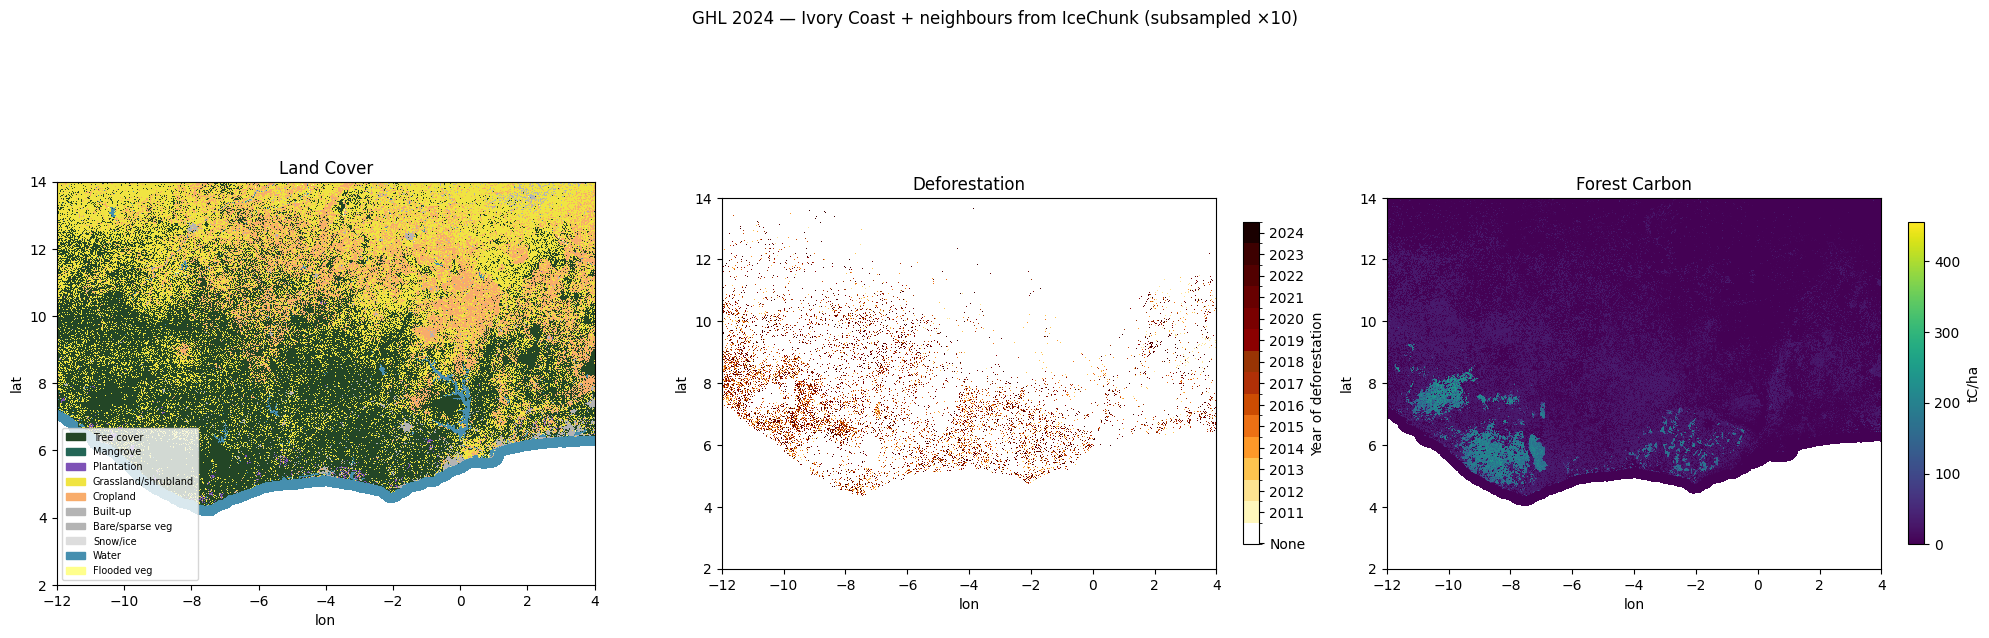

In [13]:
# ---- Visualise Ivory Coast from IceChunk ----
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

def tile_bounds(tile_name: str) -> tuple[float, float, float, float]:
    """Return (minx, miny, maxx, maxy) for a tile name e.g. '0N_0E'."""
    parts = tile_name.split("_")
    lat_str, lon_str = parts[0], parts[1]
    lat = int(lat_str[:-1]) * (-1 if lat_str[-1] == 'S' else 1)
    lon = int(lon_str[:-1]) * (-1 if lon_str[-1] == 'W' else 1)
    return (lon, lat - 10, lon + 10, lat)

# Ivory Coast + neighbours (Ghana, Burkina Faso, Guinea, Mali, Liberia)
# spans ~3 tiles: 10N_010W, 10N_000E, 20N_010W
minx, miny, maxx, maxy = -12.0, 2.0, 4.0, 14.0
plot_label = "Ivory Coast + neighbours"

bearer_token = credential.get_token("https://storage.azure.com/.default").token
storage = ic.azure_storage(
    account=ICECHUNK_ACCOUNT,
    container=ICECHUNK_CONTAINER,
    prefix=ICECHUNK_PREFIX,
    bearer_token=bearer_token,
)
repo = ic.Repository.open(storage)
ds = xr.open_dataset(
    repo.readonly_session("main").store,
    engine="zarr",
    consolidated=False,
    chunks={},
)
tile_ds = ds.sel(x=slice(minx, maxx), y=slice(maxy, miny), year=YEAR)
print(f"Region shape: {tile_ds.dims}")

# Subsample on the cluster (every 10px ≈ ~300m), pull small result back locally
SUBSAMPLE = 10
plot_ds = tile_ds.isel(x=slice(None, None, SUBSAMPLE), y=slice(None, None, SUBSAMPLE)).compute(scheduler=client)

# ── Styling ────────────────────────────────────────────────────────────────────
LC_COLORS = ['#234626','#236656','#7E52B6','#F0E442','#F8AC6B',
             '#B4B4B4','#B4B4B4','#DDDDDD','#468FAF','#FFFF8C']
LC_LABELS = ['Tree cover','Mangrove','Plantation','Grassland/shrubland',
             'Cropland','Built-up','Bare/sparse veg','Snow/ice','Water','Flooded veg']
lc_cmap = ListedColormap(LC_COLORS)
lc_norm = BoundaryNorm(np.arange(0.5, 11.5, 1), ncolors=10)

DEFOR_COLORS = ['#FFFFFF',  # 0–10: no deforestation / values not used
                '#FFF7BC','#FEE391','#FEC44F','#FE9929','#EC7014','#CC4C02',
                '#B03007','#993404','#8B0000','#7A0000','#680000','#520000',
                '#3D0000','#1A0000']
defor_cmap  = ListedColormap(DEFOR_COLORS)
# Skip the 1-10 gap entirely — merge it into the white "no deforestation" bin
defor_bounds_list = [-0.5, 10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5, 22.5, 23.5, 24.5]
defor_norm  = BoundaryNorm(defor_bounds_list, ncolors=len(defor_bounds_list) - 1)

# ── Plot ────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
extent = [minx, maxx, miny, maxy]

lc_data = plot_ds["land_cover"].squeeze().values.astype(float)
lc_data[lc_data == 255] = np.nan
axes[0].imshow(lc_data, origin="upper", extent=extent, cmap=lc_cmap, norm=lc_norm, interpolation="none")
axes[0].set_title("Land Cover")
axes[0].legend(handles=[mpatches.Patch(color=c, label=l) for c, l in zip(LC_COLORS, LC_LABELS)],
               fontsize=7, loc="lower left", framealpha=0.8)

defor_data = plot_ds["deforestation"].squeeze().values.astype(float)
defor_data[defor_data == 255] = np.nan
im_d = axes[1].imshow(defor_data, origin="upper", extent=extent, cmap=defor_cmap, norm=defor_norm, interpolation="none")
cbar_d = plt.colorbar(im_d, ax=axes[1], fraction=0.03)
cbar_d.set_ticks([0] + list(range(11, 25)))
cbar_d.set_ticklabels(["None"] + [str(2000 + v) for v in range(11, 25)])
cbar_d.set_label("Year of deforestation")
axes[1].set_title("Deforestation")

fc_data = plot_ds["forest_carbon"].squeeze().values.astype(float)
fc_data[fc_data == 65535] = np.nan
im_fc = axes[2].imshow(fc_data, origin="upper", extent=extent, cmap="viridis", vmin=0, vmax=455, interpolation="none")
plt.colorbar(im_fc, ax=axes[2], fraction=0.03).set_label("tC/ha")
axes[2].set_title("Forest Carbon")

for ax in axes:
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")

plt.suptitle(f"GHL {YEAR} — {plot_label} from IceChunk (subsampled ×{SUBSAMPLE})", y=1.01)
plt.tight_layout()
plt.show()

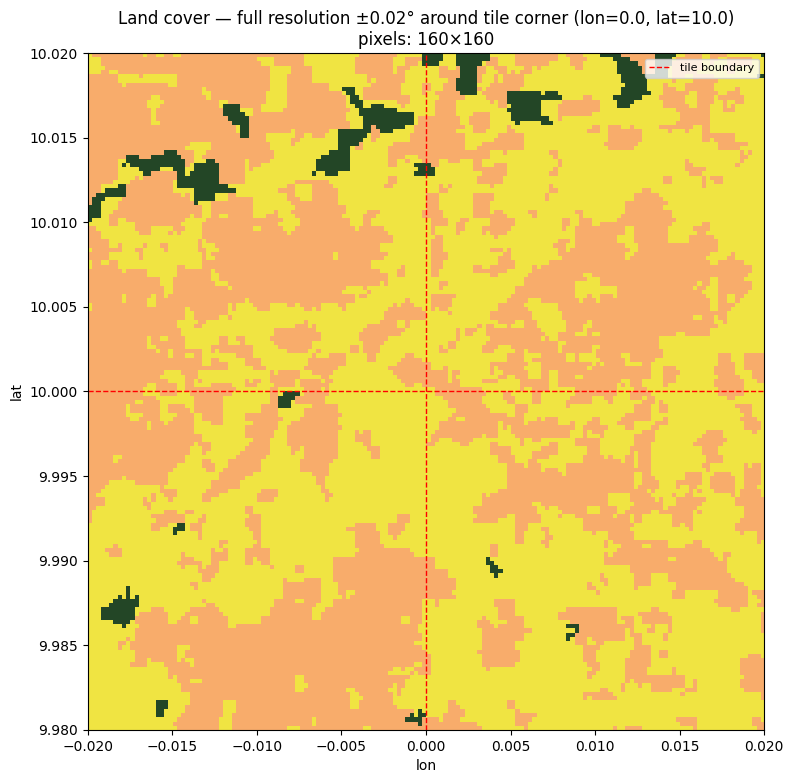

In [14]:
# ---- Tile-boundary check: full-resolution land cover at the 4-tile corner (lon=0, lat=10) ----
# Tiles meeting here: 10N_010W, 10N_000E, 20N_010W, 20N_000E
# ±0.1° = 800×800 px — small enough to load at full resolution, large enough to see the seam.
CORNER_BUFFER = 0.02  # ±0.02° = 160×160 px — shows individual pixels clearly
corner_lon, corner_lat = 0.0, 10.0

bearer_token = credential.get_token("https://storage.azure.com/.default").token
storage = ic.azure_storage(
    account=ICECHUNK_ACCOUNT, container=ICECHUNK_CONTAINER,
    prefix=ICECHUNK_PREFIX, bearer_token=bearer_token,
)
repo = ic.Repository.open(storage)
ds = xr.open_dataset(repo.readonly_session("main").store, engine="zarr", consolidated=False, chunks={})

corner_ds = ds["land_cover"].sel(
    x=slice(corner_lon - CORNER_BUFFER, corner_lon + CORNER_BUFFER),
    y=slice(corner_lat + CORNER_BUFFER, corner_lat - CORNER_BUFFER),
    year=YEAR,
).compute(scheduler=client)

lc_data = corner_ds.squeeze().values.astype(float)
lc_data[lc_data == 255] = np.nan

fig, ax = plt.subplots(figsize=(8, 8))
extent = [corner_lon - CORNER_BUFFER, corner_lon + CORNER_BUFFER,
          corner_lat - CORNER_BUFFER, corner_lat + CORNER_BUFFER]
ax.imshow(lc_data, origin="upper", extent=extent, cmap=lc_cmap, norm=lc_norm, interpolation="none")
# Mark the tile boundary lines
ax.axvline(corner_lon, color="red", linewidth=1, linestyle="--", label="tile boundary")
ax.axhline(corner_lat, color="red", linewidth=1, linestyle="--")
ax.set_xlabel("lon"); ax.set_ylabel("lat")
ax.legend(loc="upper right", fontsize=8)
ax.set_title(
    f"Land cover — full resolution ±{CORNER_BUFFER}° around tile corner (lon={corner_lon}, lat={corner_lat})\n"
    f"pixels: {lc_data.shape[1]}×{lc_data.shape[0]}"
)
plt.tight_layout()
plt.show()

In [18]:
# ---- Landscape-scale GIF: Central Amazon deforestation — with zoom-out ----
# Fetches data at the widest extent; each key frame is rendered at a progressively
# wider crop window, creating a smooth zoom-out across the animation.
import io
from PIL import Image as PILImage

DPI = 100

def fig_to_pil(fig):
    """Render a matplotlib figure to a PIL Image (no whitespace padding)."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=DPI, bbox_inches="tight", pad_inches=0)
    plt.close(fig)
    buf.seek(0)
    return PILImage.open(buf).copy()


# EPSG 6933 point (-5810530E, -1257470N) → WGS84 lon=-60.22°, lat=-9.90°
# Central Amazon, Brazil — active deforestation hotspot
_CENTER_LON, _CENTER_LAT = -60.2213, -9.9048

# Zoom schedule: animation starts zoomed in, ends zoomed out
_AOI_HALF = 0.44   # ±0.44° → ~49 km
_AOI_HALF_FETCH = _AOI_HALF + 0.02   # fetch a little extra to avoid edge artefacts


LANDSCAPE_LABEL = "Central Amazon, Brazil"
LANDSCAPE_SUBSAMPLE = 2  # every 2px → ~60m

# Fetch data at the maximum (widest) extent once
bearer_token = credential.get_token("https://storage.azure.com/.default").token
storage = ic.azure_storage(
    account=ICECHUNK_ACCOUNT, container=ICECHUNK_CONTAINER,
    prefix=ICECHUNK_PREFIX, bearer_token=bearer_token,
)
repo = ic.Repository.open(storage)
ds = xr.open_dataset(repo.readonly_session("main").store, engine="zarr", consolidated=False, chunks={})

landscape_raw = (
    ds.sel(
        x=slice(_CENTER_LON - _AOI_HALF_FETCH, _CENTER_LON + _AOI_HALF_FETCH),
        y=slice(_CENTER_LAT + _AOI_HALF_FETCH, _CENTER_LAT - _AOI_HALF_FETCH),
        year=YEAR,
    )
    .isel(x=slice(None, None, LANDSCAPE_SUBSAMPLE), y=slice(None, None, LANDSCAPE_SUBSAMPLE))
    .compute(scheduler=client)
)

_full_lc    = landscape_raw["land_cover"].squeeze().values.astype(float);    _full_lc[_full_lc == 255]       = np.nan
_full_defor = landscape_raw["deforestation"].squeeze().values.astype(float); _full_defor[_full_defor == 255]  = np.nan
_full_fc    = landscape_raw["forest_carbon"].squeeze().values.astype(float); _full_fc[_full_fc == 65535]      = np.nan
_xv = landscape_raw.x.values   # 1-D, ascending
_yv = landscape_raw.y.values   # 1-D, descending (north → south)

LS_FIGSIZE = (10, 8)

def _bare_ax(ax):
    ax.set_axis_off()

def crossfade(img_a, img_b, steps=8):
    """Return steps blended PIL frames transitioning from img_a to img_b."""
    a = img_a.convert("RGBA")
    b = img_b.convert("RGBA")
    if b.size != a.size:
        b = b.resize(a.size, PILImage.LANCZOS)
    return [PILImage.blend(a, b, i / (steps + 1)).convert("RGB") for i in range(1, steps + 1)]

def crop_at_zoom(arr_full, half_deg):
    """Return (cropped_array, imshow_extent) for a ±half_deg window around centre."""
    xi = np.where((    _xv >= _CENTER_LON - half_deg) & (_xv <= _CENTER_LON + half_deg))[0]
    yi = np.where((    _yv >= _CENTER_LAT - half_deg) & (_yv <= _CENTER_LAT + half_deg))[0]
    if len(xi) == 0 or len(yi) == 0:
        return arr_full, [_xv[0], _xv[-1], _yv[-1], _yv[0]]
    cropped = arr_full[yi[0] : yi[-1] + 1, xi[0] : xi[-1] + 1]
    # extent for imshow: [left, right, bottom, top]
    extent = [_xv[xi[0]], _xv[xi[-1]], min(_yv[yi[0]], _yv[yi[-1]]), max(_yv[yi[0]], _yv[yi[-1]])]
    return cropped, extent



# Fixed zoom: all frames rendered at _AOI_HALF



# ── Helper: render a deforestation frame at a given zoom ──────────────────────
def make_defor_frame(up_to_year_code, half_deg):
    """White-background deforestation ≤ up_to_year_code, cropped to half_deg."""
    _dc = ListedColormap(DEFOR_COLORS)
    _dc.set_bad(color="white", alpha=1)
    d, ext = crop_at_zoom(_full_defor, half_deg)
    d = d.copy()
    d[(d == 0) | (d > up_to_year_code)] = np.nan
    fig, ax = plt.subplots(figsize=LS_FIGSIZE)
    ax.set_facecolor("white"); fig.patch.set_facecolor("white")
    ax.imshow(d, origin="upper", extent=ext, cmap=_dc, norm=defor_norm, interpolation="none")
    _bare_ax(ax); plt.tight_layout(pad=0)
    return fig_to_pil(fig)

# ── Helper: render the land-cover frame at a given zoom ───────────────────────
def make_lc_frame(half_deg):
    arr, ext = crop_at_zoom(_full_lc, half_deg)
    fig, ax = plt.subplots(figsize=LS_FIGSIZE)
    ax.imshow(arr, origin="upper", extent=ext, cmap=lc_cmap, norm=lc_norm, interpolation="none")
    _bare_ax(ax); plt.tight_layout(pad=0)
    return fig_to_pil(fig)

# ── Helper: render the forest-carbon frame at a given zoom ────────────────────
def make_fc_frame(half_deg):
    arr, ext = crop_at_zoom(_full_fc, half_deg)
    arr = arr.copy(); arr[arr == 0] = np.nan
    valid = arr[~np.isnan(arr)]
    vmin = float(np.percentile(valid, 2))  if len(valid) else 1
    vmax = float(np.percentile(valid, 98)) if len(valid) else 455
    _cmap = plt.get_cmap("viridis").copy(); _cmap.set_bad(alpha=0)
    fig, ax = plt.subplots(figsize=LS_FIGSIZE)
    ax.imshow(arr, origin="upper", extent=ext, cmap=_cmap, vmin=vmin, vmax=vmax, interpolation="none")
    _bare_ax(ax); plt.tight_layout(pad=0)
    return fig_to_pil(fig)

# ── Build all key frames ───────────────────────────────────────────────────────
HOLD_MS       = 4000   # LC and FC hold — equal to defor section total
FADE_STEPS    = 8
FADE_STEP_MS  = 60
YEAR_HOLD_MS  = 250    # 11 frames x 250ms + 10 fades x 2 x 60ms ≈ 4000ms
YEAR_FADE     = 2      # quick crossfades between years


# Deforestation key frames, one per beat slot 0–5
defor_year_seq = [(yc, YEAR_HOLD_MS) for yc in range(14, 25)]  # 2014–2024
defor_key_frames = [make_defor_frame(yc, _AOI_HALF) for yc, _ in defor_year_seq]
defor_holds      = [dur for _, dur in defor_year_seq]

kf_lc = make_lc_frame(_AOI_HALF)
kf_fc = make_fc_frame(_AOI_HALF)

# ── Assemble: deforestation → land cover → forest carbon (looping) ─────────────
all_frames    = []
all_durations = []

# Part 1: progressive deforestation with short crossfades between years
for i, (df, dur) in enumerate(zip(defor_key_frames, defor_holds)):
    all_frames.append(df); all_durations.append(dur)
    if i < len(defor_key_frames) - 1:
        for f in crossfade(df, defor_key_frames[i + 1], steps=YEAR_FADE):
            all_frames.append(f); all_durations.append(FADE_STEP_MS)

# Part 2: crossfade last defor → land cover, hold
for f in crossfade(defor_key_frames[-1], kf_lc, steps=FADE_STEPS):
    all_frames.append(f); all_durations.append(FADE_STEP_MS)
all_frames.append(kf_lc); all_durations.append(HOLD_MS)

# Part 3: crossfade land cover → forest carbon, hold
for f in crossfade(kf_lc, kf_fc, steps=FADE_STEPS):
    all_frames.append(f); all_durations.append(FADE_STEP_MS)
all_frames.append(kf_fc); all_durations.append(HOLD_MS)

# Loop back: crossfade forest carbon → first defor frame
for f in crossfade(kf_fc, defor_key_frames[0], steps=FADE_STEPS):
    all_frames.append(f); all_durations.append(FADE_STEP_MS)

# ── Save GIF ───────────────────────────────────────────────────────────────────
LS_GIF_PATH = pathlib.Path("ghl_landscape_animation.gif")
all_frames[0].save(
    LS_GIF_PATH,
    save_all=True,
    append_images=all_frames[1:],
    duration=all_durations,
    loop=0,
)
print(f"Landscape GIF saved → {LS_GIF_PATH.resolve()}  ({LS_GIF_PATH.stat().st_size / 1024:.0f} KB)")
print(f"Landscape GIF saved -> {LS_GIF_PATH.resolve()}  ({LS_GIF_PATH.stat().st_size / 1024:.0f} KB), {len(all_frames)} total frames")


Landscape GIF saved → /Users/alexandermackie/PycharmProjects/si-integrations/integrations/earthmover/ghl/ghl_landscape_animation.gif  (9663 KB)
Landscape GIF saved -> /Users/alexandermackie/PycharmProjects/si-integrations/integrations/earthmover/ghl/ghl_landscape_animation.gif  (9663 KB), 57 total frames


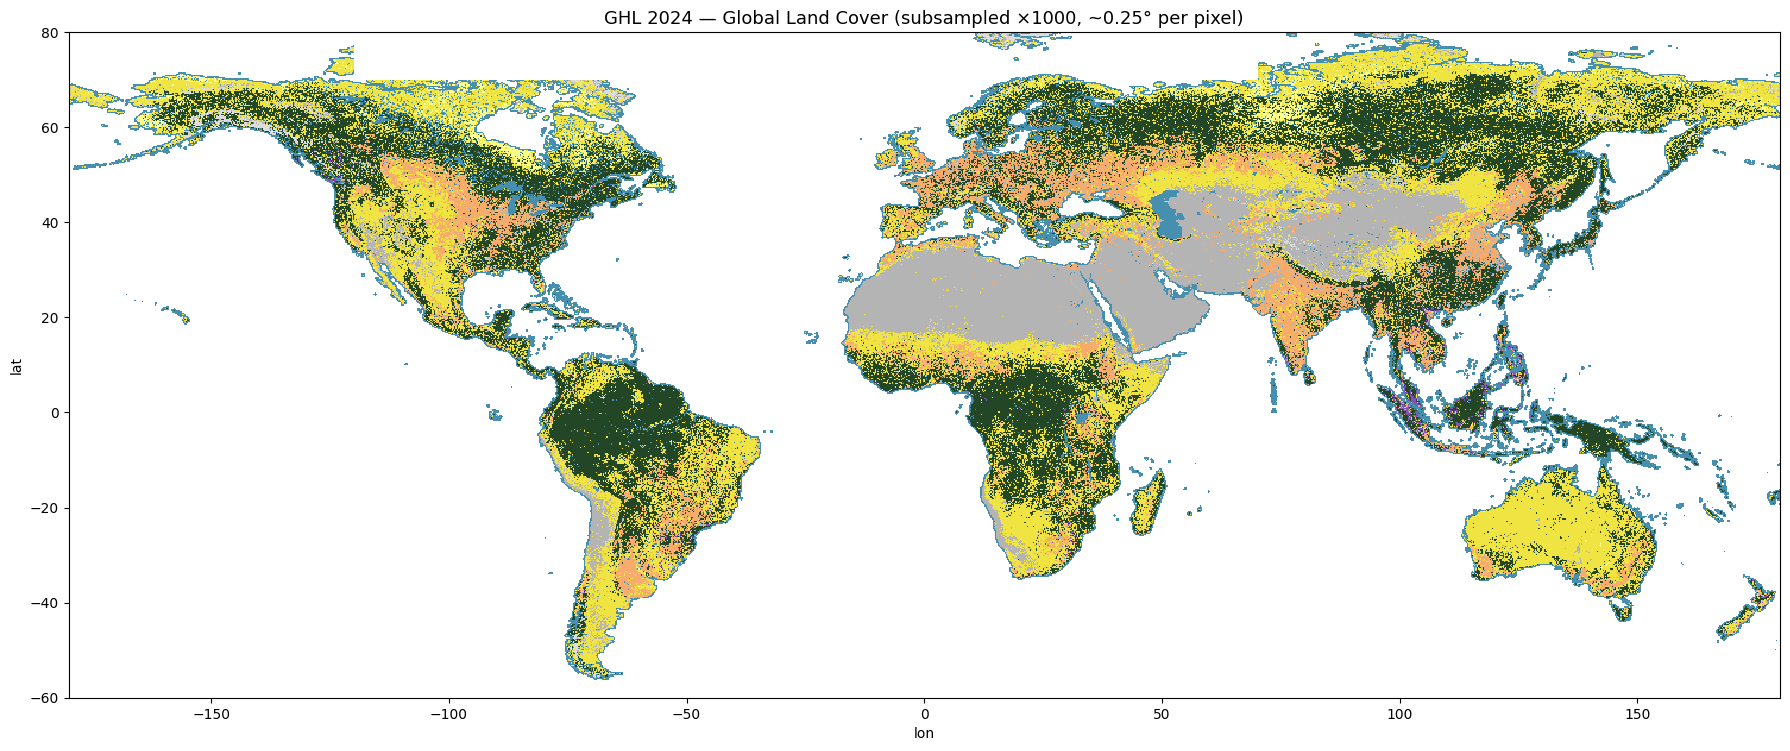

In [19]:
# ---- Global overview: very coarse land cover from IceChunk ----
# Subsample every 1000px → ~0.25° spacing (~28 km); pulls the full global grid
# in a fraction of the time. Good for a quick sanity-check that all tiles are written.
GLOBAL_SUBSAMPLE = 1000

bearer_token = credential.get_token("https://storage.azure.com/.default").token
storage = ic.azure_storage(
    account=ICECHUNK_ACCOUNT, container=ICECHUNK_CONTAINER,
    prefix=ICECHUNK_PREFIX, bearer_token=bearer_token,
)
repo = ic.Repository.open(storage)
ds_global = xr.open_dataset(
    repo.readonly_session("main").store,
    engine="zarr",
    consolidated=False,
    chunks={},
)

global_lc_raw = (
    ds_global["land_cover"]
    .sel(year=YEAR)
    .isel(x=slice(None, None, GLOBAL_SUBSAMPLE), y=slice(None, None, GLOBAL_SUBSAMPLE))
    .compute(scheduler=client)
)

global_lc = global_lc_raw.values.astype(float)
global_lc[global_lc == 255] = np.nan  # mask nodata

fig, ax = plt.subplots(figsize=(18, 8))
ax.imshow(
    global_lc,
    origin="upper",
    extent=[-180, 180, -60, 80],
    cmap=lc_cmap,
    norm=lc_norm,
    interpolation="none",
)
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_title(
    f"GHL {YEAR} — Global Land Cover (subsampled ×{GLOBAL_SUBSAMPLE}, ~{GLOBAL_SUBSAMPLE * 0.00025:.2f}° per pixel)",
    fontsize=13,
)
plt.tight_layout()
plt.show()